## Imports

In [114]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler as sc
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression


# model tuning and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# model metrics
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
import numpy as np

## Model making

In [131]:
df_clean = pd.read_csv("cleaned.csv")
df_clean

,Unnamed: 0,id,intakereason,istransfer,breedname,speciesname,animalage,sexname,location,movementtype,...,isdoa,intake_date,intake_time,movement_date,movement_time,return_date,return_time,death_date,death_time,age_in_months
0,0,15801,Moving,0,Domestic Short Hair,Cat,9 years 2 months.,Female,Adoptable Cat Glass Colony,Adoption,...,0,2009-11-28,00:00:00,2017-05-13,00:00:00,NaN,NaN,NaN,NaN,110.00
1,1,15932,Moving,0,German Shepherd Dog/Mix,Dog,9 years 1 month.,Male,Adoptable Dogs,Adoption,...,0,2009-12-08,00:00:00,2017-04-24,00:00:00,NaN,NaN,NaN,NaN,109.00
2,2,28859,Abandoned,0,Shep Mix/Siberian Husky,Dog,6 years 8 months.,Female,Adoptable Dogs,Adoption,...,0,2012-08-10,00:00:00,2017-04-15,00:00:00,NaN,NaN,NaN,NaN,80.00
3,3,30812,Abandoned,0,Domestic Short Hair,Cat,8 years 11 months.,Female,Stray Cats,Foster,...,0,2013-01-11,00:00:00,2017-04-18,00:00:00,2018-05-29,00:00:00,NaN,NaN,107.00
4,4,30812,Abandoned,0,Domestic Short Hair,Cat,8 years 11 months.,Female,Stray Cats,Adoption,...,0,2013-01-11,00:00:00,2018-05-29,00:00:00,NaN,NaN,NaN,NaN,107.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10285,10285,64584,Litter relinquishment,0,Domestic Medium Hair,Cat,21 weeks.,Male,Cat room C,Adoption,...,0,2019-08-27,16:52:09,2019-08-29,00:00:00,NaN,NaN,NaN,NaN,4.83
10286,10286,64588,Stray,0,Domestic Short Hair,Cat,6 weeks.,Female,Cat room C,Foster,...,0,2019-08-27,18:14:11,2019-08-28,00:00:00,NaN,NaN,NaN,NaN,1.38
10287,10287,64606,Stray,0,Coonhound,Dog,6 years 8 months.,Male,Dog room B,Reclaimed,...,0,2019-08-29,12:10:21,2019-08-29,00:00:00,NaN,NaN,NaN,NaN,80.00
10288,10288,64608,Stray,0,Beagle,Dog,7 years 5 months.,Female,Canine intake room,Reclaimed,...,0,2019-08-29,18:58:06,2019-08-30,00:00:00,NaN,NaN,NaN,NaN,89.00


In [132]:
df_clean.isna().sum()

Unnamed: 0           0
id                   0
intakereason         0
istransfer           0
breedname           45
speciesname          0
animalage            0
sexname              0
location             0
movementtype         0
returnedreason       0
deceasedreason       0
diedoffshelter       0
puttosleep           0
isdoa                0
intake_date          0
intake_time          0
movement_date        0
movement_time        0
return_date       7034
return_time       7034
death_date        9964
death_time        9964
age_in_months        0
dtype: int64

In [133]:
df_clean = df_clean.drop(['id', 'Unnamed: 0', 'intake_date', 'intake_time','movement_date', 'movement_time', 'return_date', 'return_time', 'death_date', 'death_time', 'breedname', 'animalage'], axis = 1)
df_clean

,intakereason,istransfer,speciesname,sexname,location,movementtype,returnedreason,deceasedreason,diedoffshelter,puttosleep,isdoa,age_in_months
0,Moving,0,Cat,Female,Adoptable Cat Glass Colony,Adoption,Stray,Died in care,0,0,0,110.00
1,Moving,0,Dog,Male,Adoptable Dogs,Adoption,Stray,Died in care,0,0,0,109.00
2,Abandoned,0,Dog,Female,Adoptable Dogs,Adoption,Stray,Died in care,0,0,0,80.00
3,Abandoned,0,Cat,Female,Stray Cats,Foster,Stray,Died in care,0,0,0,107.00
4,Abandoned,0,Cat,Female,Stray Cats,Adoption,Stray,Died in care,0,0,0,107.00
...,...,...,...,...,...,...,...,...,...,...,...,...
10285,Litter relinquishment,0,Cat,Male,Cat room C,Adoption,Stray,Court Order/ Legal,0,0,0,4.83
10286,Stray,0,Cat,Female,Cat room C,Foster,Stray,Court Order/ Legal,0,0,0,1.38
10287,Stray,0,Dog,Male,Dog room B,Reclaimed,Stray,Court Order/ Legal,0,0,0,80.00
10288,Stray,0,Dog,Female,Canine intake room,Reclaimed,Stray,Court Order/ Legal,0,0,0,89.00


In [134]:
df_clean.isna().sum()

intakereason      0
istransfer        0
speciesname       0
sexname           0
location          0
movementtype      0
returnedreason    0
deceasedreason    0
diedoffshelter    0
puttosleep        0
isdoa             0
age_in_months     0
dtype: int64

In [135]:
X = df_clean.drop(['returnedreason'], axis = 1)
y = df_clean['returnedreason']
X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

PCA

In [136]:
pca = PCA(n_components=10)

x_train = pca.fit_transform(X_train)
x_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_

explained_variance_ratio = pca.explained_variance_ratio_
for indx, evr in enumerate(explained_variance_ratio):
    print(f"PC{indx+1}: {evr:.2f}")

PC1: 1.00
PC2: 0.00
PC3: 0.00
PC4: 0.00
PC5: 0.00
PC6: 0.00
PC7: 0.00
PC8: 0.00
PC9: 0.00
PC10: 0.00


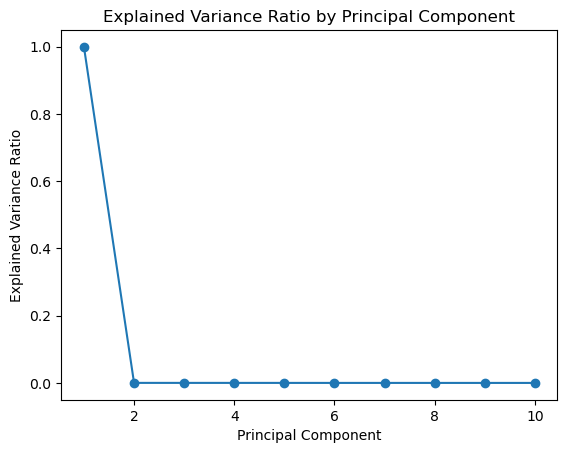

In [137]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
# set x and y values
x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
# plot
ax.plot(x, y, marker='o')
# set label and title
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

In [138]:
feature_names = X_train.columns

In [139]:
# Accessing the component weights
component_weights = pca.components_
#print("Component Weights:\n", component_weights)
# Create a mapping between component weights and feature names
feature_weights_mapping = {}
for i, component in enumerate(component_weights):
    component_feature_weights = zip(feature_names, component)
    feature_weights_mapping[f"Component {i+1}"] = sorted(
      component_feature_weights, key=lambda x: abs(x[1]), reverse=True)
    
# Accessing feature names contributing to Component 1
print("Feature names contributing to Component 1:")
for feature, weight in feature_weights_mapping["Component 1"]:
    print(f"{feature}: {weight}")

# Accessing feature names contributing to Component 2
print("Feature names contributing to Component 2:")
for feature, weight in feature_weights_mapping["Component 2"]:
    print(f"{feature}: {weight}")

Feature names contributing to Component 1:
age_in_months: 0.9999966820404411
movementtype_Reclaimed: 0.0010899141464803975
speciesname_Dog: 0.0009896699794816903
movementtype_Foster: -0.0009047695668712623
speciesname_Cat: -0.0008840885289650659
movementtype_Adoption: -0.0008367376109259483
movementtype_Transfer: 0.0006246551747550194
intakereason_Litter relinquishment: -0.000607199503875069
sexname_Unknown: 0.0005333706571337632
location_Adoptable window colony: -0.00039862766936122034
location_Stray Cats: 0.00035949488193729454
intakereason_Stray: 0.00035866140260400566
sexname_Male: -0.0003337606718739154
location_Lobby: -0.0002780646178331204
location_Adoptable Cat Small Colony: -0.0002647425535555416
location_Check-in: 0.00021541761118251595
location_Cat room A: -0.00021430710198566032
location_Adoptable Cat Glass Colony: -0.00021312682029583853
sexname_Female: -0.00019960998525984998
location_Cat room C: 0.00016079052858505838
location_Stray Dogs Beta: 0.0001477157536989646
locat

## Model

### Decision Tree:

In [140]:
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
   # Replace with actual column names

# Preprocessor for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="mean"), numerical_features),  # Impute missing values for numerical features
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),  # Impute missing values for categorical features
            ("onehot", OneHotEncoder(handle_unknown="ignore"))  # One-hot encode categorical features
        ]), categorical_features),
    ]
)
# create pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA()),
        ("classifier", DecisionTreeClassifier(random_state=42)),
          ])
# define parameter grid
param_grid = {
    'pca__n_components': [2, 3, 4, 5, 10, 15,20,25],
    'classifier__max_depth': [2,3, 4, 5, 10],
}

# setup grid search and cross-validation
tuned_model = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
)
train = tuned_model.fit(X_train, y_train)
# print search results
print("Best parameters found:", train.best_params_)
print("Best cross-validated accuracy:", train.best_score_)

# evaluate and print test metrics
y_te = train.predict(X_test)
print(f"Test accuracy:", accuracy_score(y_true = y_test, y_pred = y_te))
print(f"Test recall:", recall_score(y_true=y_test, y_pred=y_te, average='macro'))
print(f"Test precision:", precision_score(y_true=y_test, y_pred=y_te, average='macro'))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters found: {'classifier__max_depth': 2, 'pca__n_components': 4}
Best cross-validated accuracy: 0.932094732423398
Test accuracy: 0.9368318756073858
Test recall: 0.05625
Test precision: 0.09684005833738454


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
100 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 469, in fit
    Xt = self._fit(X, y, ro

In [91]:
test_score = tuned_model.score(X_test, y_test)
test_score

0.9368318756073858

### HistGradientBoosting

In [112]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="mean"), numerical_features),  # Impute missing values for numerical features
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),  # Impute missing values for categorical features
            ("onehot", OneHotEncoder(handle_unknown="ignore"))  # One-hot encode categorical features
        ]), categorical_features),
    ]
)
# create pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA()),
        ("classifier", HistGradientBoostingClassifier(random_state=42)),
          ])
# define parameter grid
param_grid = {
    'pca__n_components': [2, 3, 4, 5, 10, 15,20,25],
    'classifier__max_depth': [2,3, 4, 5, 10],
}

# setup grid search and cross-validation
tuned_model = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
)
train = tuned_model.fit(X_train, y_train)
# print search results
print("Best parameters found:", train.best_params_)
print("Best cross-validated accuracy:", train.best_score_)

# evaluate and print test metrics
y_te = train.predict(X_test)
print(f"Test accuracy:", accuracy_score(y_true = y_test, y_pred = y_te))
print(f"Test recall:", recall_score(y_true=y_test, y_pred=y_te, average='macro'))
print(f"Test precision:", precision_score(y_true=y_test, y_pred=y_te, average='macro'))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
100 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(e

Best parameters found: {'classifier__max_depth': 5, 'pca__n_components': 2}
Best cross-validated accuracy: 0.8432996109868011
Test accuracy: 0.8974732750242954
Test recall: 0.04792423456149455
Test precision: 0.046759493670886075


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Random Forest:

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="mean"), numerical_features),  # Impute missing values for numerical features
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),  # Impute missing values for categorical features
            ("onehot", OneHotEncoder(handle_unknown="ignore"))  # One-hot encode categorical features
        ]), categorical_features),
    ]
)
# create pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA()),
        ("classifier", RandomForestClassifier(random_state=42)),
          ])
# define parameter grid
param_grid = {
    'pca__n_components': [2, 3, 4, 5, 10, 15,20,25],
    'classifier__max_depth': [2,3, 4, 5, 10],
}

# setup grid search and cross-validation
tuned_model = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
)
train = tuned_model.fit(X_train, y_train)
# print search results
print("Best parameters found:", train.best_params_)
print("Best cross-validated accuracy:", train.best_score_)

# evaluate and print test metrics
y_te = train.predict(X_test)
print(f"Test accuracy:", accuracy_score(y_true = y_test, y_pred = y_te))
print(f"Test recall:", recall_score(y_true=y_test, y_pred=y_te, average='macro'))
print(f"Test precision:", precision_score(y_true=y_test, y_pred=y_te, average='macro'))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
100 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(e

Best parameters found: {'classifier__max_depth': 2, 'pca__n_components': 2}
Best cross-validated accuracy: 0.9330661219153938
Test accuracy: 0.9363459669582118
Test recall: 0.05
Test precision: 0.04681729834791059


C:\Users\Trish\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [83]:
rfc = 0.9330661219153938
dt = 0.932094732423398
rfc>dt

True

In [67]:
dt-rfc

1.4754909882785938e-07